# 1. Introduction and Project Overview

In [1]:
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import yaml
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import shutil
! pip install ultralytics
from ultralytics import YOLO
import cv2
from pathlib import Path
import torch, gc
from collections import Counter



print("Libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.3

# 2. Data Loading and Initial Exploration

In [2]:
dataset_path = Path("/kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8")
processed_dataset_path = Path("/kaggle/working/BoneFracture_Preprocessed")
results_path = Path("/kaggle/working/results")
os.makedirs(results_path, exist_ok=True)

print(f"📂 Original dataset: {dataset_path}")
print(f"📁 Processed dataset will be saved to: {processed_dataset_path}")

yolo_names = [
    "elbow positive", "fingers positive", "forearm fracture",
    "humerus fracture", "humerus", "shoulder fracture", "wrist positive"
]


for split in ["train", "valid", "test"]:
    (processed_dataset_path / split / "images").mkdir(parents=True, exist_ok=True)
    (processed_dataset_path / split / "labels").mkdir(parents=True, exist_ok=True)
print("✅ Created directory structure.")

# --- CLAHE preprocessing ---
def preprocess_image(image_path):
    """Apply CLAHE and mild denoise for X-ray enhancement."""
    img = cv2.imread(str(image_path))
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Optional light blur to suppress noise
    enhanced = cv2.GaussianBlur(enhanced, (3, 3), 0)

    # Normalize and convert to 3-channel
    enhanced = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)
    enhanced_rgb = cv2.merge([enhanced, enhanced, enhanced])
    return enhanced_rgb

# --- Utility: count classes in label folder ---
def get_label_distribution(labels_dir):
    counts = Counter()
    for f in Path(labels_dir).glob("*.txt"):
        try:
            with open(f) as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 1:
                        cls = int(float(parts[0]))
                        counts[cls] += 1
        except Exception:
            continue
    return counts

# --- Harder classes identified empirically ---
hard_classes = ["wrist positive", "elbow positive", "shoulder fracture"]

# --- Main preprocessing & balancing loop ---
image_files_info = []

for split in ["train", "valid", "test"]:
    images_dir = dataset_path / split / "images"
    labels_dir = dataset_path / split / "labels"
    output_images_dir = processed_dataset_path / split / "images"
    output_labels_dir = processed_dataset_path / split / "labels"

    if not images_dir.exists():
        print(f"⚠️ Missing folder: {images_dir}, skipping {split}.")
        continue

    label_counts = get_label_distribution(labels_dir)
    if not label_counts:
        continue

    total_labels = sum(label_counts.values()) or 1
    avg_count = total_labels / len(label_counts)
    background_class = max(label_counts, key=label_counts.get)
    minority_classes = [cls for cls, c in label_counts.items() if c < avg_count * 0.5]

    print(f"\n📊 {split.upper()} class distribution: {label_counts}")
    print(f"⚖️ Downsampling class {background_class}, Oversampling minority: {minority_classes}")

    for img_file in tqdm(os.listdir(images_dir), desc=f"Processing {split} images"):
        img_name, ext = os.path.splitext(img_file)
        if ext.lower() not in ('.jpg', '.jpeg', '.png'):
            continue

        label_path = labels_dir / f"{img_name}.txt"
        if not label_path.exists():
            continue

        try:
            with open(label_path) as f:
                lines = f.readlines()
                classes = [int(float(line.strip().split()[0])) for line in lines if line.strip()]
            if not classes:
                continue
            cls_id = classes[0]
        except Exception:
            continue

        # --- Downsample dominant (background-heavy) class ---
        if cls_id == background_class and random.random() < 0.6:
            continue

        # --- Oversample rare & hard classes ---
        oversample_factor = 1
        class_name = yolo_names[cls_id]
        if cls_id in minority_classes or class_name in hard_classes:
            oversample_factor = 2

        # --- Process and save (with augmentation for hard classes) ---
        img = preprocess_image(images_dir / img_file)
        if img is None:
            continue

        for idx in range(oversample_factor):
            aug_img = img.copy()

            # Apply light geometric augmentations for oversampled ones
            if oversample_factor > 1 and random.random() < 0.7:
                if random.random() < 0.5:
                    aug_img = cv2.flip(aug_img, 1)
                if random.random() < 0.5:
                    angle = random.uniform(-10, 10)
                    h, w = aug_img.shape[:2]
                    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1)
                    aug_img = cv2.warpAffine(aug_img, M, (w, h))

            new_name = f"{img_name}_{idx}.jpg"
            cv2.imwrite(str(output_images_dir / new_name), aug_img, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
            shutil.copy(label_path, output_labels_dir / f"{img_name}_{idx}.txt")

            h, w = aug_img.shape[:2]
            image_files_info.append({
                "split": split,
                "image_name": new_name,
                "width": w,
                "height": h,
                "class": cls_id
            })

print("\n✅ Preprocessing, balancing, and selective augmentation complete!")

# --- Summary of processed data ---
all_images_df = pd.DataFrame(image_files_info)
print(f"\n📊 Total processed images: {len(all_images_df)}")
display(all_images_df.groupby("class").size().rename("count"))

# --- YOLOv8 YAML ---
yaml_path_for_yolo = Path("/kaggle/working/data.yaml")

yaml_content = f"""
path: {processed_dataset_path}
train: train/images
val: valid/images
test: test/images

nc: {len(yolo_names)}
names: {yolo_names}
"""

with open(yaml_path_for_yolo, "w") as f:
    f.write(yaml_content)

print(f"\n✅ data.yaml saved at: {yaml_path_for_yolo}")
print(f"Classes ({len(yolo_names)}): {yolo_names}")

📂 Original dataset: /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8
📁 Processed dataset will be saved to: /kaggle/working/BoneFracture_Preprocessed
✅ Created directory structure.

📊 TRAIN class distribution: Counter({1: 531, 5: 360, 0: 339, 2: 316, 4: 311, 6: 228, 3: 3})
⚖️ Downsampling class 1, Oversampling minority: [3]


Processing train images:   0%|          | 0/3631 [00:00<?, ?it/s]


📊 VALID class distribution: Counter({1: 48, 2: 43, 4: 36, 0: 29, 6: 28, 5: 20})
⚖️ Downsampling class 1, Oversampling minority: []


Processing valid images:   0%|          | 0/348 [00:00<?, ?it/s]


📊 TEST class distribution: Counter({1: 27, 0: 17, 5: 17, 4: 15, 2: 14, 6: 6})
⚖️ Downsampling class 1, Oversampling minority: [6]


Processing test images:   0%|          | 0/169 [00:00<?, ?it/s]


✅ Preprocessing, balancing, and selective augmentation complete!

📊 Total processed images: 2661


class
0    694
1    210
2    333
4    344
5    698
6    382
Name: count, dtype: int64


✅ data.yaml saved at: /kaggle/working/data.yaml
Classes (7): ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']


# 3. Exploratory Data Analysis (EDA) and Visualization 


🔍 Sample images with bounding boxes and (if any) segmentation masks:


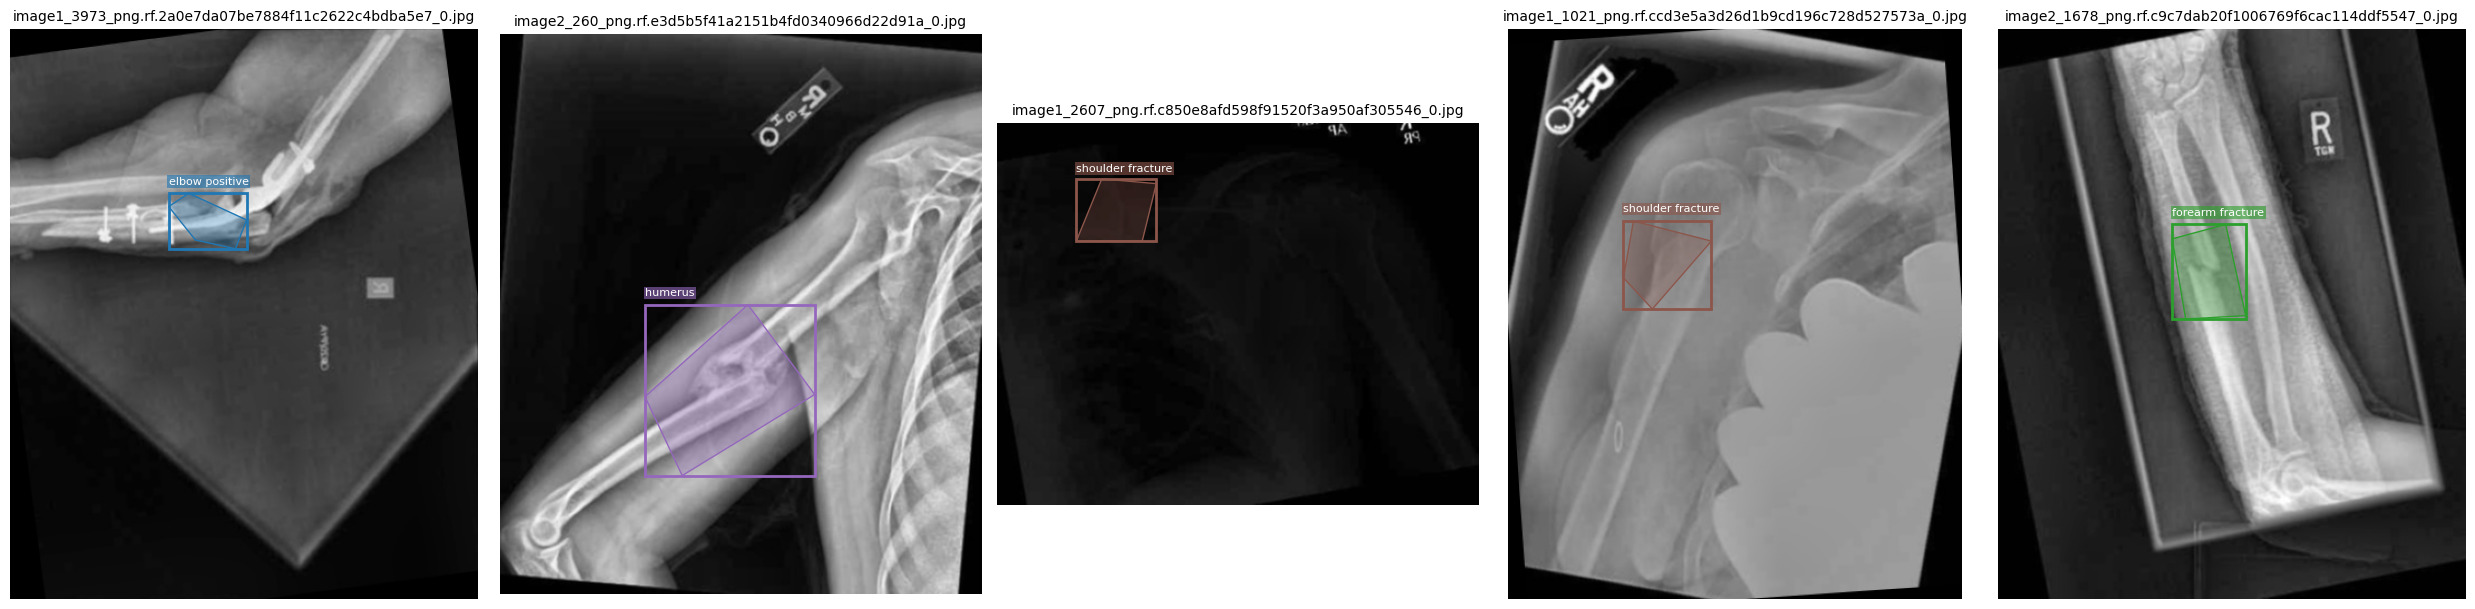

In [3]:
def parse_yolo_annotation(label_path, img_width, img_height):
    """
    Parse YOLO-format annotations.
    Supports both bounding boxes (5 values) and segmentation polygons (>5 values).
    Returns: boxes, class_ids, polygons
    """
    boxes, class_ids, polygons = [], [], []
    label_path = Path(label_path)
    
    if not label_path.exists():
        return boxes, class_ids, polygons

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                print(f"⚠️ Skipping malformed annotation: {line.strip()}")
                continue

            try:
                class_id = int(float(parts[0]))
                values = np.array(parts[1:], dtype=float)

                if len(values) == 4:
                    # Bounding box (YOLO normalized cx, cy, w, h)
                    cx, cy, w, h = values
                    xmin = int((cx - w / 2) * img_width)
                    ymin = int((cy - h / 2) * img_height)
                    xmax = int((cx + w / 2) * img_width)
                    ymax = int((cy + h / 2) * img_height)
                    boxes.append([xmin, ymin, xmax, ymax])
                    class_ids.append(class_id)
                    polygons.append(None)

                elif len(values) > 4:
                    # Polygon segmentation points
                    poly_coords = values.reshape(-1, 2)
                    poly_pixels = (poly_coords * np.array([img_width, img_height])).astype(np.int32)
                    polygons.append(poly_pixels)
                    class_ids.append(class_id)
                    xmin, ymin = np.min(poly_pixels, axis=0)
                    xmax, ymax = np.max(poly_pixels, axis=0)
                    boxes.append([xmin, ymin, xmax, ymax])

            except Exception as e:
                print(f"⚠️ Error parsing line: {line.strip()} — {e}")
                continue

    return boxes, class_ids, polygons


# --- Visualization ---
def plot_images_with_boxes_yolo(split_dir, num_images=5, class_names=None):
    """
    Show sample images with bounding boxes and segmentation masks.
    """
    split_dir = Path(split_dir)
    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"

    image_files = [f for f in img_dir.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png")]
    if not image_files:
        print(f"⚠️ No images found in {img_dir}")
        return

    sampled_files = np.random.choice(image_files, min(num_images, len(image_files)), replace=False)

    plt.figure(figsize=(5 * num_images, 6))
    for i, img_path in enumerate(sampled_files):
        label_path = lbl_dir / f"{img_path.stem}.txt"

        img = Image.open(img_path).convert("RGB")
        img_w, img_h = img.size
        boxes, class_ids, polygons = parse_yolo_annotation(label_path, img_w, img_h)

        ax = plt.subplot(1, num_images, i + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(img_path.name, fontsize=10)

        # Draw boxes/polygons
        for box, cls_id, poly in zip(boxes, class_ids, polygons):
            color = plt.cm.tab10(cls_id % 10)  # consistent distinct colors
            xmin, ymin, xmax, ymax = box
            rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 fill=False, edgecolor=color, linewidth=2)
            ax.add_patch(rect)

            if poly is not None and len(poly) > 0:
                ax.add_patch(plt.Polygon(poly, closed=True, facecolor=color[:3] + (0.3,), edgecolor=color, linewidth=1))

            # Label text box
            label = class_names[cls_id] if class_names and cls_id < len(class_names) else f"Class_{cls_id}"
            ax.text(xmin, ymin - 8, label, color="white", fontsize=8,
                    bbox=dict(facecolor=color, alpha=0.6, edgecolor="none", pad=1))

    plt.tight_layout()
    plt.show()


# --- Run visualization ---
print("\n🔍 Sample images with bounding boxes and (if any) segmentation masks:")
plot_images_with_boxes_yolo(
    split_dir=processed_dataset_path / "train",
    num_images=5,
    class_names=yolo_names
)

# 4. Model Training (YOLOv8)

In [4]:
gc.collect()
torch.cuda.empty_cache()

print("\n🚀 Starting YOLOv8m high-resolution training...")

# --- Initialize YOLOv8m model ---
# Larger backbone than v8s, pretrained on COCO
model = YOLO("yolov8m.pt")

# --- Training configuration ---
results = model.train(
    data=str(yaml_path_for_yolo),       # dataset YAML
    epochs=100,                         # slightly longer for m model
    imgsz=800,                          # high-res X-rays
    batch=8,                            # fits in T4 (auto if you prefer)
    device=0,                           # GPU
    workers=2,                          # safe threading
    pretrained=True,                    # start from COCO weights
    optimizer="AdamW",                  # better for small data
    cos_lr=True,                        # cosine annealing
    lr0=0.0015,                         # slightly lower LR (stabilizes m)
    lrf=1e-3,
    weight_decay=0.015,
    warmup_epochs=3,
    momentum=0.9,

    # --- Augmentation tuning (robust but medical-safe) ---
    hsv_h=0.015, hsv_s=0.5, hsv_v=0.3,
    degrees=5.0, translate=0.08, scale=0.6, shear=2.0,
    fliplr=0.3, flipud=0.0,
    mosaic=0.9, mixup=0.3, copy_paste=0.0,
    erasing=0.1, perspective=0.0,
    close_mosaic=10,
    auto_augment=True,

    # --- Training management ---
    patience=25,
    amp=True,
    cache=True,
    save=True,
    save_period=0,
    project="/kaggle/working/runs",
    name="bone_fracture_yolov8m_highres",
    exist_ok=True,

    # --- Regularization and loss tuning ---
    box=7.0, cls=0.7, dfl=1.5,
    label_smoothing=0.05,
)

print("\n✅ YOLOv8m Training complete!")

# --- Display summary metrics if available ---
if hasattr(model, 'metrics') and model.metrics:
    m = model.metrics
    print(f"📈 Final mAP50: {m.box.map50:.4f} | mAP50-95: {m.box.map:.4f}")
else:
    print("Training complete — check /kaggle/working/runs for full results.")


🚀 Starting YOLOv8m high-resolution training...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.221 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=True, batch=8, bgr=0.0, box=7.0, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.7, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.1, exist_ok=True, fliplr=0.3, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0015, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8m.pt, momentum=0.9, mosaic=0.9, multi_scale=False, name=bone_fracture_yolov8m_highr

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        212        253      0.327      0.274      0.257     0.0958
        elbow positive         56         58     0.0284     0.0172     0.0136    0.00302
      fingers positive         16         20      0.459       0.34       0.36      0.143
      forearm fracture         37         43      0.563      0.488      0.467      0.177
               humerus         31         36      0.406      0.583      0.533      0.195
     shoulder fracture         38         40      0.305      0.125      0.105     0.0265
        wrist positive         34         56      0.201     0.0893      0.064     0.0304
Speed: 0.3ms preprocess, 13.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /kaggle/working/runs/bone_fracture_yolov8m_highres

✅ YOLOv8m Training complete!
📈 Final mAP50: 0.2570 | mAP50-95: 0.0958


# 5. Model Evaluation and Analysis

📂 Detected latest run: bone_fracture_yolov8m_highres
✅ Loaded model from: /kaggle/working/runs/bone_fracture_yolov8m_highres/weights/best.pt
Ultralytics 8.3.221 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 817.0±190.0 MB/s, size: 29.6 KB)
val: Scanning /kaggle/working/BoneFracture_Preprocessed/valid/labels.cache... 212 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 212/212 399.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 3.6it/s 7.4s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        212        253      0.382      0.249      0.336      0.132
        elbow positive         56         58          0          0          0          0
      fingers positive         16         20      0.473        0.3      0.431      0.176
      forearm fracture         37         43      0.645      0.465      0.557      0.236
               humerus         31         36       0.55      0.577      0.642       0.24
     shoulder fracture         38         40      0.394        0.1      0.237     0.0653
        wrist positive         34         56      0.231     0.0536      0.149     0.0736
Speed: 1.9ms preprocess, 30.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

📊 Validation Metrics:
mAP50:     0.3359
mAP50-95:  0.1319
Precision: 0.3822
Recall:    0.2492

📄 Metrics saved to /kaggle/working/results/validation_summary.csv


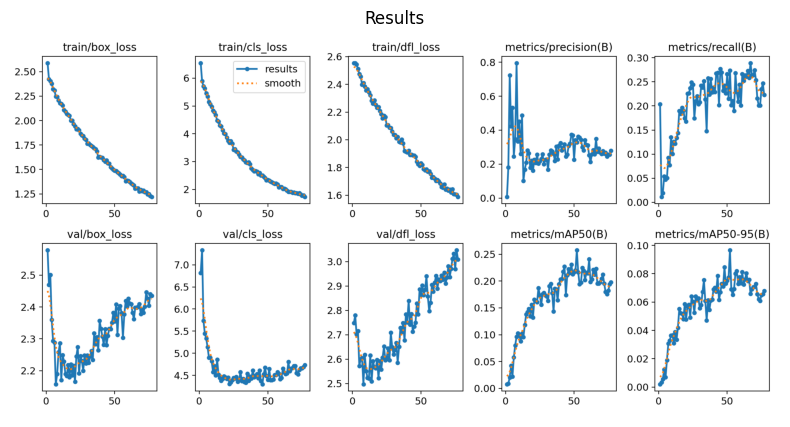

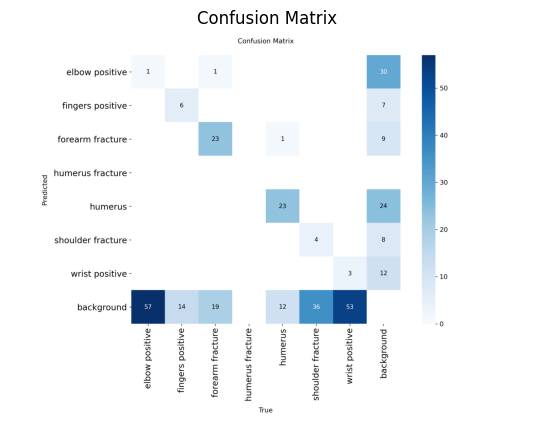

⚠️ PR_curve.png not found in /kaggle/working/runs/bone_fracture_yolov8m_highres

✅ Validation complete. Full results saved under:
/kaggle/working/runs/bone_fracture_yolov8m_highres


In [5]:

# --- Automatically detect latest run directory ---
runs_dir = Path("/kaggle/working/runs")
latest_run = max(runs_dir.glob("bone_fracture_yolov8*"), key=os.path.getmtime)
print(f"📂 Detected latest run: {latest_run.name}")

# --- Load best weights automatically ---
best_weights = latest_run / "weights" / "best.pt"
if not best_weights.exists():
    raise FileNotFoundError(f"❌ best.pt not found in {latest_run}/weights")

model = YOLO(str(best_weights))
print(f"✅ Loaded model from: {best_weights}")

# --- Run validation ---
metrics = model.val(
    data=str(yaml_path_for_yolo),
    imgsz=800,               # match training resolution
    batch=8,                 # safe for Kaggle T4 GPU
    device=0,
    workers=2,
    plots=True,              # saves PR curves, confusion matrix, etc.
    save_json=False,
    conf=0.25,
    iou=0.5,
    verbose=True
)

# --- Extract and print metrics safely ---
print("\n📊 Validation Metrics:")

try:
    results_dict = getattr(metrics, "results_dict", {})
    mAP50     = results_dict.get("metrics/mAP50(B)", None)
    mAP5095   = results_dict.get("metrics/mAP50-95(B)", None)
    precision = results_dict.get("metrics/precision(B)", None)
    recall    = results_dict.get("metrics/recall(B)", None)

    if mAP50 is not None:
        print(f"mAP50:     {mAP50:.4f}")
    if mAP5095 is not None:
        print(f"mAP50-95:  {mAP5095:.4f}")
    if precision is not None:
        print(f"Precision: {precision:.4f}")
    if recall is not None:
        print(f"Recall:    {recall:.4f}")

    # --- Save summary CSV for tracking ---
    summary_csv = Path("/kaggle/working/results/validation_summary.csv")
    pd.DataFrame([{
        "run_name": latest_run.name,
        "mAP50": mAP50,
        "mAP50-95": mAP5095,
        "precision": precision,
        "recall": recall
    }]).to_csv(summary_csv, index=False)
    print(f"\n📄 Metrics saved to {summary_csv}")

except Exception as e:
    print("⚠️ Could not parse metrics — check YOLOv8 version or results dict format.")
    print(e)

# --- Display available result plots ---
plots_to_show = ["results.png", "confusion_matrix.png", "PR_curve.png"]

for plot_name in plots_to_show:
    plot_path = latest_run / plot_name
    if plot_path.exists():
        plt.figure(figsize=(10, 5))
        plt.imshow(Image.open(plot_path))
        plt.title(plot_name.replace(".png", "").replace("_", " ").title(), fontsize=12)
        plt.axis("off")
        plt.show()
    else:
        print(f"⚠️ {plot_name} not found in {latest_run}")

print("\n✅ Validation complete. Full results saved under:")
print(latest_run)

# 6. Inference and Visualization of Predictions

✅ Loaded model for visualization: /kaggle/working/runs/bone_fracture_yolov8m_highres/weights/best.pt


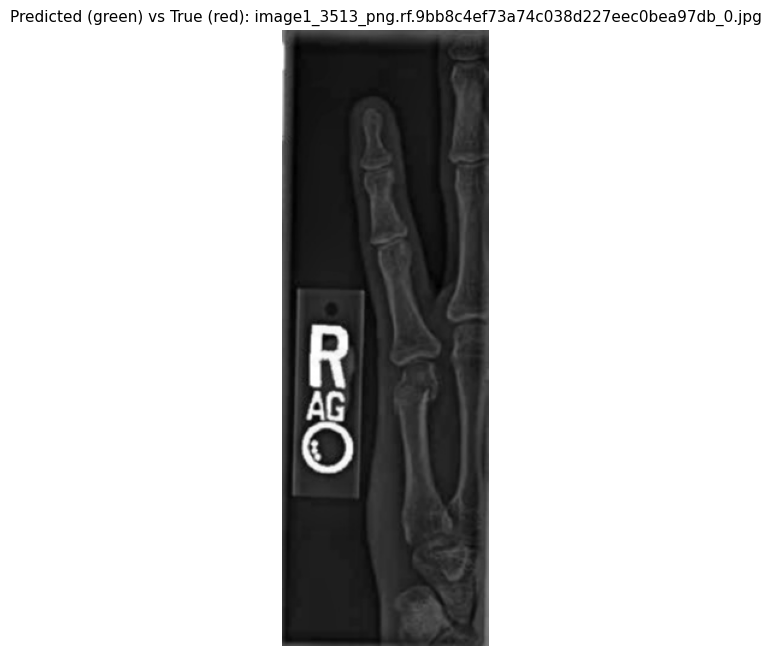

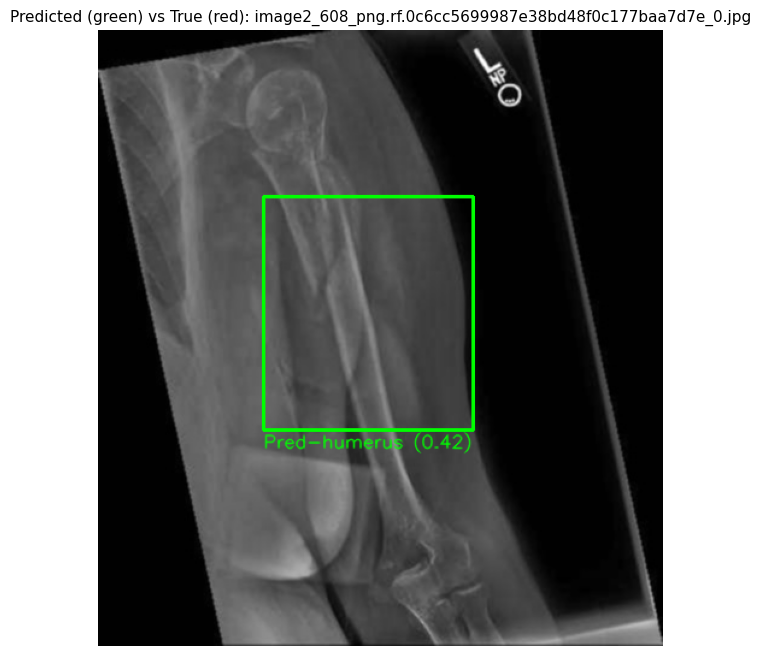

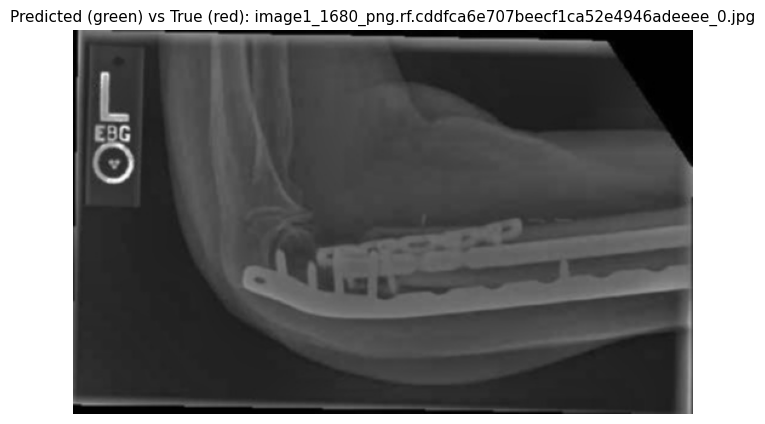

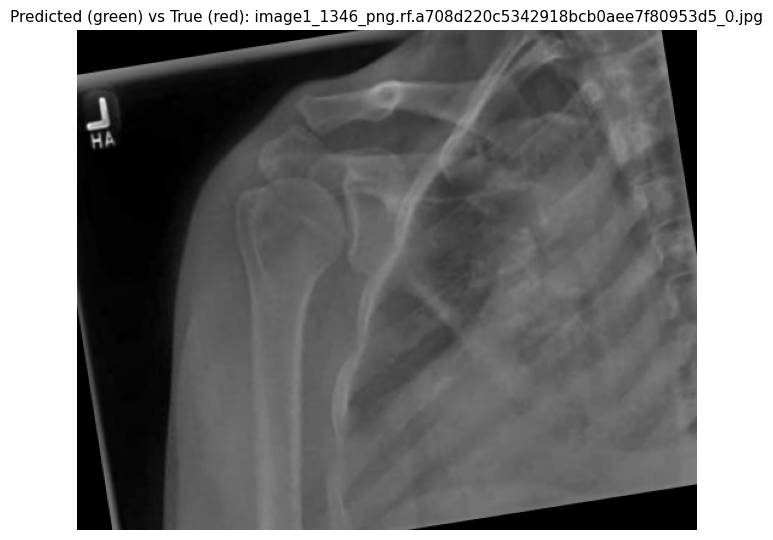

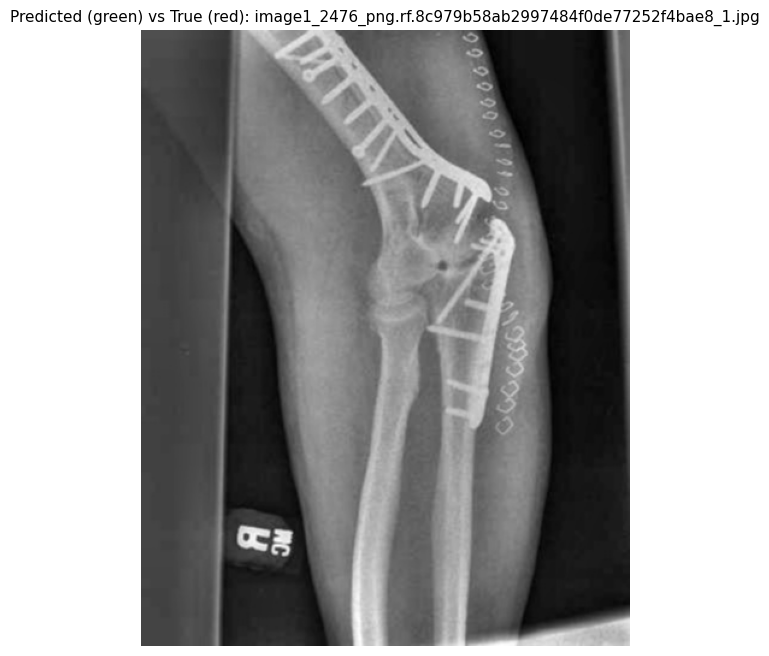


✅ Comparison images saved in: /kaggle/working/results/pred_vs_true


In [6]:
# --- Load best model automatically ---
runs_dir = Path("/kaggle/working/runs")
latest_run = max(runs_dir.glob("bone_fracture_yolov8*"), key=os.path.getmtime)
best_model_path = latest_run / "weights" / "best.pt"

model = YOLO(str(best_model_path))
print(f"✅ Loaded model for visualization: {best_model_path}")

# --- Define paths ---
val_img_dir = Path("/kaggle/working/BoneFracture_Preprocessed/valid/images")
val_lbl_dir = Path("/kaggle/working/BoneFracture_Preprocessed/valid/labels")
save_dir = Path("/kaggle/working/results/pred_vs_true")
save_dir.mkdir(parents=True, exist_ok=True)

# --- Helper: parse YOLO label ---
def parse_yolo_label(label_path, img_w, img_h):
    boxes, classes = [], []
    if not Path(label_path).exists():
        return boxes, classes
    with open(label_path) as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            if len(parts) == 5:
                cls, cx, cy, w, h = parts
                x1 = int((cx - w/2) * img_w)
                y1 = int((cy - h/2) * img_h)
                x2 = int((cx + w/2) * img_w)
                y2 = int((cy + h/2) * img_h)
                boxes.append((x1, y1, x2, y2))
                classes.append(int(cls))
    return boxes, classes

# --- Visualize predictions vs ground truth ---
sample_images = list(val_img_dir.glob("*.jpg"))[:10]  # first 10 validation images
random.shuffle(sample_images)

for img_path in sample_images[:5]:  # visualize 5 random samples
    img = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]
    label_path = val_lbl_dir / (img_path.stem + ".txt")

    # --- Ground Truth (Red) ---
    gt_boxes, gt_classes = parse_yolo_label(label_path, img_w, img_h)
    for (x1, y1, x2, y2), cls in zip(gt_boxes, gt_classes):
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(img, f"GT-{model.names[cls]}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)

    # --- Predictions (Green) ---
    preds = model.predict(source=str(img_path), conf=0.25, iou=0.5, verbose=False)
    for r in preds:
        if r.boxes is None:
            continue
        for box, cls_id, conf in zip(r.boxes.xyxy.cpu().numpy(),
                                     r.boxes.cls.cpu().numpy(),
                                     r.boxes.conf.cpu().numpy()):
            x1, y1, x2, y2 = box.astype(int)
            label = f"Pred-{model.names[int(cls_id)]} ({conf:.2f})"
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, label, (x1, y2 + 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    # --- Save and display ---
    save_path = save_dir / f"pred_vs_true_{img_path.name}"
    cv2.imwrite(str(save_path), img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title(f"Predicted (green) vs True (red): {img_path.name}", fontsize=11)
    plt.axis("off")
    plt.show()

print(f"\n✅ Comparison images saved in: {save_dir}")